<a href="https://colab.research.google.com/github/Kamo3131/MIO-fuzzy-logic/blob/main/MIO_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_PATH = "/content/drive/Shareddrives/MIO-fuzzy-logic/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
pip install ucimlrepo

In [46]:
import os
import pandas as pd
FILE_NAME = "winequality-red.csv"
full_file_path = os.path.join(DRIVE_PATH, FILE_NAME)

df = pd.read_csv(full_file_path, sep=';')

X = df.drop(columns=['quality'])
y = df[['quality']]

print("Rozmiar wczytanej macierzy cech X:", X.shape)
print("Rozmiar wektora wyjściowego y:", y.shape)
print("\nPierwsze 3 wiersze cech:")
print(X.head(3))

Rozmiar wczytanej macierzy cech X: (1599, 11)
Rozmiar wektora wyjściowego y: (1599, 1)

Pierwsze 3 wiersze cech:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  
0      9.4  
1      9.8  
2      9.8  


In [47]:
print(X.describe())
print(y.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

In [48]:
import pandas as pd

full_data = pd.concat([X, y], axis=1)

correlations = full_data.corr()['quality'].sort_values(ascending=False)
print("Korelacja cech z jakością wina:")
print(correlations)

Korelacja cech z jakością wina:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [49]:
!pip install scikit-fuzzy

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

wybrane_cechy = ['alcohol', 'volatile acidity', 'sulphates']
X_reduced = X[wybrane_cechy]
X_reduced_min = dict()
X_reduced_max = dict()

for col in wybrane_cechy:
    min_val = X_reduced[col].min()
    max_val = X_reduced[col].max()
    X_reduced_min[col] = min_val
    X_reduced_max[col] = max_val
    print(f"Zmienna '{col}': zakres od {min_val} do {max_val}")

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

Zmienna 'alcohol': zakres od 8.4 do 14.9
Zmienna 'volatile acidity': zakres od 0.12 do 1.58
Zmienna 'sulphates': zakres od 0.33 do 2.0


In [51]:
polowa = len(X_reduced) // 2

X_train = X_reduced.iloc[:polowa]
X_test = X_reduced.iloc[polowa:]

y_train = y.iloc[:polowa]
y_test = y.iloc[polowa:]

print(f"Wymiary zbioru uczącego: {X_train.shape}")
print(f"Wymiary zbioru testowego: {X_test.shape}")

Wymiary zbioru uczącego: (799, 3)
Wymiary zbioru testowego: (800, 3)


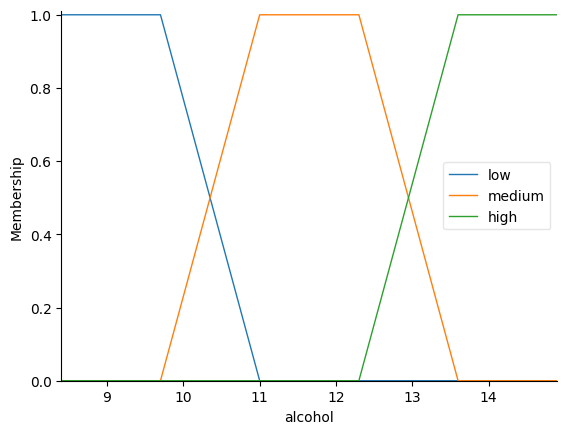

In [52]:
from skfuzzy import control as ctrl
import skfuzzy as fuzz
alcohol = ctrl.Antecedent(np.arange(X_reduced_min['alcohol'], X_reduced_max['alcohol']+0.1, 0.1), 'alcohol')

alcohol_dif = X_reduced_max['alcohol'] - X_reduced_min['alcohol']
alcohol['low'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol'],
                                               X_reduced_min['alcohol'],
                                               X_reduced_min['alcohol']+0.2*alcohol_dif,
                                               X_reduced_min['alcohol']+0.4*alcohol_dif])
alcohol['medium'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol']+0.2*alcohol_dif,
                                                  X_reduced_min['alcohol']+0.4*alcohol_dif,
                                                  X_reduced_min['alcohol']+0.6*alcohol_dif,
                                                  X_reduced_min['alcohol']+0.8*alcohol_dif])
alcohol['high'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol']+0.6*alcohol_dif,
                                                X_reduced_min['alcohol']+0.8*alcohol_dif,
                                                X_reduced_max['alcohol'],
                                                X_reduced_max['alcohol']])

alcohol.view()

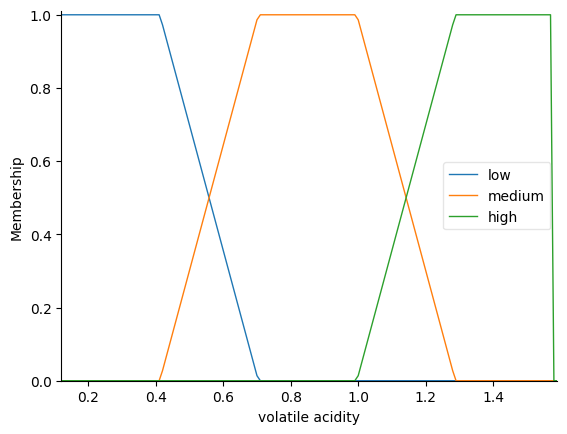

In [53]:
volatile_acidity = ctrl.Antecedent(np.arange(X_reduced_min['volatile acidity'], X_reduced_max['volatile acidity']+0.01, 0.01), 'volatile acidity')

volatile_acidity_dif = X_reduced_max['volatile acidity'] - X_reduced_min['volatile acidity']
volatile_acidity['low'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity'],
                                               X_reduced_min['volatile acidity'],
                                               X_reduced_min['volatile acidity']+0.2*volatile_acidity_dif,
                                               X_reduced_min['volatile acidity']+0.4*volatile_acidity_dif])
volatile_acidity['medium'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity']+0.2*volatile_acidity_dif,
                                                  X_reduced_min['volatile acidity']+0.4*volatile_acidity_dif,
                                                  X_reduced_min['volatile acidity']+0.6*volatile_acidity_dif,
                                                  X_reduced_min['volatile acidity']+0.8*volatile_acidity_dif])
volatile_acidity['high'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity']+0.6*volatile_acidity_dif,
                                                X_reduced_min['volatile acidity']+0.8*volatile_acidity_dif,
                                                X_reduced_max['volatile acidity'],
                                                X_reduced_max['volatile acidity']])

volatile_acidity.view()

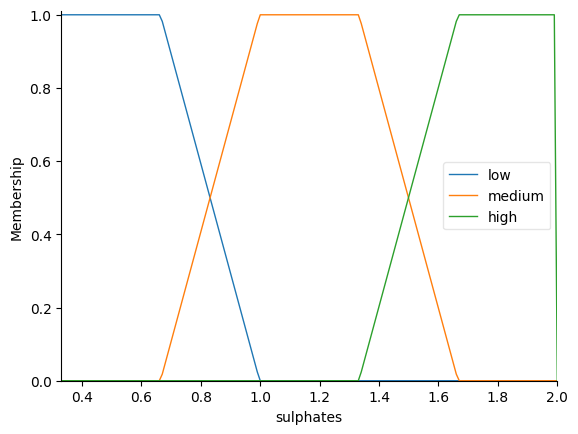

In [54]:
sulphates = ctrl.Antecedent(np.arange(X_reduced_min['sulphates'], X_reduced_max['sulphates']+0.01, 0.01), 'sulphates')

sulphates_dif = X_reduced_max['sulphates'] - X_reduced_min['sulphates']
sulphates['low'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates'],
                                               X_reduced_min['sulphates'],
                                               X_reduced_min['sulphates']+0.2*sulphates_dif,
                                               X_reduced_min['sulphates']+0.4*sulphates_dif])
sulphates['medium'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates']+0.2*sulphates_dif,
                                                  X_reduced_min['sulphates']+0.4*sulphates_dif,
                                                  X_reduced_min['sulphates']+0.6*sulphates_dif,
                                                  X_reduced_min['sulphates']+0.8*sulphates_dif])
sulphates['high'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates']+0.6*sulphates_dif,
                                                X_reduced_min['sulphates']+0.8*sulphates_dif,
                                                X_reduced_max['sulphates'],
                                                X_reduced_max['sulphates']])

sulphates.view()

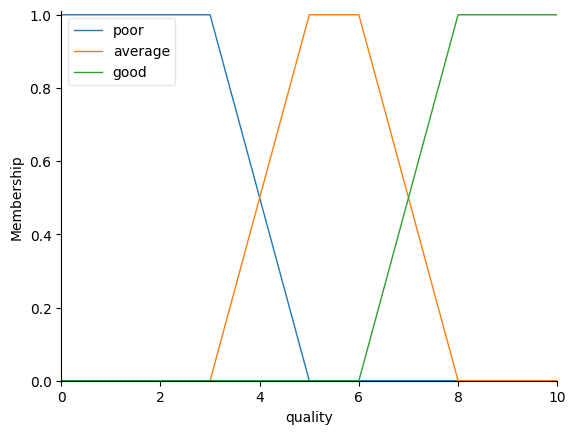

In [55]:
quality = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'quality')

quality['poor'] = fuzz.trapmf(quality.universe, [0, 0, 3, 5])
quality['average'] = fuzz.trapmf(quality.universe, [3, 5, 6, 8])
quality['good'] = fuzz.trapmf(quality.universe, [6, 8, 10, 10])

quality.view()